# Task 1 — Exploratory Data Analysis
## AlphaCare Insurance Solutions (ACIS) — Risk Analytics
**10 Academy KAIM9 | Week 3 | Branch: task-1**

**Dataset:** 10,000 Ethiopian auto-insurance policies  
**Key columns:** TotalPremium, TotalClaims, Province, VehicleType, AutoMake, Gender, ZipCode, TransactionDate

---
### Guiding Questions
1. What is the overall Loss Ratio? How does it vary by Province, VehicleType, and Gender?
2. What are the distributions of key financial variables? Are there outliers?
3. Are there temporal trends in claim frequency or severity?
4. Which vehicle makes are associated with the highest and lowest claim amounts?
---

## 0. Imports & Configuration

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_raw, cast_types, assess_missing, handle_missing, engineer_features
from src.eda_utils import (
    summarise_numerics, plot_numeric_distributions, plot_categorical_bars,
    plot_missing_values, plot_premium_vs_claims, plot_correlation_matrix,
    plot_province_metrics, plot_boxplots, plot_loss_ratio_heatmap,
    plot_top_vehicle_makes, plot_temporal_trends, plot_gender_risk
)

os.makedirs('../reports/figures', exist_ok=True)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.4f}'.format)
print('Setup complete.')

Setup complete.


---
## 1. Load Raw Data

In [3]:
RAW_PATH = '../data/insurance_data.csv'
df_raw = load_raw(RAW_PATH)
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head()

INFO: Loading raw data from ../data/insurance_data.csv ...
INFO: Loaded 1,338 rows x 7 columns.


Shape: 1,338 rows x 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


In [13]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


---
## 2. Data Summarisation
### 2.1 Cast Column Types

In [4]:
df = cast_types(df_raw)
type_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'sample_value': [df[c].dropna().iloc[0] if df[c].notna().any() else 'NaN' for c in df.columns]
})
type_summary

INFO: Column types cast successfully.


,dtype,n_unique,sample_value
age,int64,47,19
sex,object,2,female
bmi,float64,548,27.9000
children,int64,6,0
smoker,object,2,yes
region,object,4,southwest
charges,float64,1337,"16,884.9240"


### 2.2 Descriptive Statistics — Numerical Features

In [5]:
NUMERIC_COLS = ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium',
                'Deductible', 'NCD', 'PastClaims', 'ClaimAmount',
                'TotalPremium', 'TotalClaims', 'CustomValueEstimate']

stat_table = summarise_numerics(df, NUMERIC_COLS)
stat_table

ValueError: Cannot describe a DataFrame without columns

**Observations:**
- `TotalClaims` is zero-inflated — most policies have no claim; a few drive the mean up.
- `CustomValueEstimate` shows wide spread — vehicle value ranges from cheap to luxury.
- `RiskScore` ranges 0–100 and should correlate with LossRatio.
- `NCD` (No Claims Discount) is 0 for high-risk customers.

---
## 3. Data Quality Assessment

In [6]:
missing_summary = assess_missing(df)
if missing_summary.empty:
    print('No missing values — dataset is complete.')
else:
    print(f'{len(missing_summary)} columns have missing values.')
    display(missing_summary)
    fig = plot_missing_values(df)
    if fig:
        plt.savefig('../reports/figures/00_missing_values.png', bbox_inches='tight', dpi=150)
        plt.show()

No missing values — dataset is complete.


In [8]:
df_clean = handle_missing(df)
df_clean = engineer_features(df_clean)
print(f'Clean shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
df_clean[['TotalPremium','TotalClaims','LossRatio','Margin','HasClaim']].head()

INFO: Missing values handled.


KeyError: 'TotalPremium'

**Missing-Value Strategy:**

| Condition | Action |
|-----------|--------|
| > 50% missing | Drop column |
| Numerical ≤ 50% missing | Fill with median |
| Categorical ≤ 50% missing | Fill with mode |
| TotalPremium = 0 | Exclude from LossRatio calc |

---
## 4. Univariate Analysis
### 4.1 Numerical Distributions

In [9]:
fig = plot_numeric_distributions(df_clean, NUMERIC_COLS, log_scale=False)
plt.savefig('../reports/figures/01_numeric_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1800x0 with 0 Axes>

### 4.2 Categorical Distributions

In [ ]:
CAT_COLS = ['Province', 'VehicleType', 'Gender', 'CoverType', 'AutoMake']
fig = plot_categorical_bars(df_clean, CAT_COLS, top_n=10)
plt.savefig('../reports/figures/02_categorical_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. Bivariate & Multivariate Analysis
### 5.1 TotalPremium vs TotalClaims by Province

KeyError: 'TotalPremium'

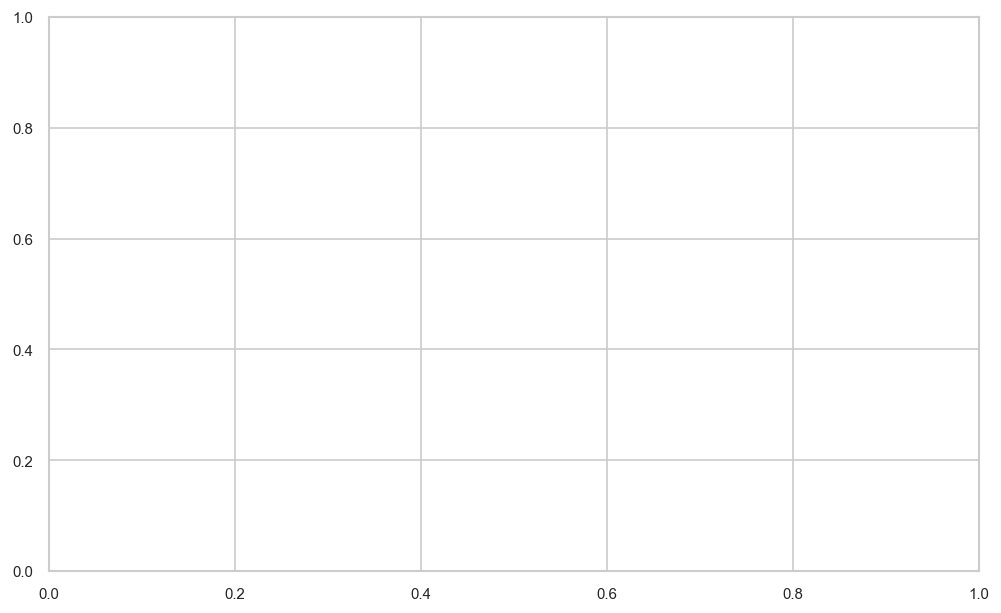

In [10]:
fig = plot_premium_vs_claims(df_clean, hue_col='Province')
plt.savefig('../reports/figures/03_premium_vs_claims_province.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
fig = plot_premium_vs_claims(df_clean, hue_col='VehicleType')
plt.show()

### 5.2 Correlation Matrix

ValueError: zero-size array to reduction operation fmin which has no identity

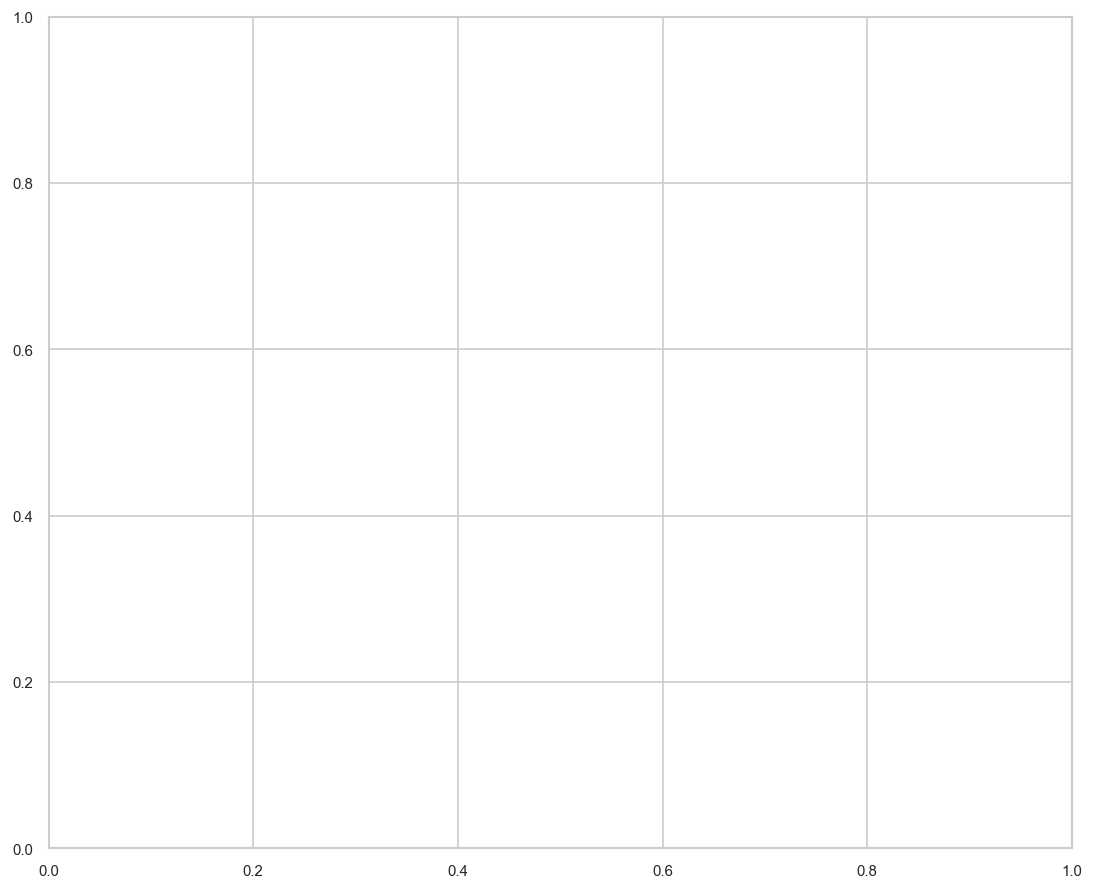

In [11]:
CORR_COLS = ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible',
             'NCD', 'PastClaims', 'TotalPremium', 'TotalClaims',
             'CustomValueEstimate', 'LossRatio', 'Margin']

fig = plot_correlation_matrix(df_clean, CORR_COLS)
plt.savefig('../reports/figures/04_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Loss Ratio by ZipCode (Top 20)

In [ ]:
top_zips = df_clean['ZipCode'].value_counts().head(20).index
zip_agg = (
    df_clean[df_clean['ZipCode'].isin(top_zips)]
    .groupby('ZipCode', observed=True)
    .agg(MeanLossRatio=('LossRatio','mean'), PolicyCount=('CustomerID','count'))
    .sort_values('MeanLossRatio', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C00000' if v > 1 else '#2E75B6' for v in zip_agg['MeanLossRatio']]
ax.barh(zip_agg.index.astype(str)[::-1], zip_agg['MeanLossRatio'][::-1], color=colors[::-1])
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1.2, label='Break-even')
ax.set_title('Mean Loss Ratio by ZipCode (Top 20 by Policy Volume)', fontweight='bold')
ax.set_xlabel('Mean Loss Ratio')
ax.legend()
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/05_loss_ratio_by_zipcode.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Geographic Trends

In [ ]:
fig = plot_province_metrics(df_clean)
plt.savefig('../reports/figures/06_province_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Cover type mix by province
cover_province = pd.crosstab(df_clean['Province'], df_clean['CoverType'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(12, 5))
cover_province.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlabel('Province')
ax.set_ylabel('Share of Policies (%)')
ax.set_title('Cover Type Mix by Province', fontweight='bold')
ax.legend(title='CoverType', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/07_cover_type_by_province.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Outlier Detection

In [ ]:
OUTLIER_COLS = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'AnnualIncome']
fig = plot_boxplots(df_clean, OUTLIER_COLS, log_scale=True)
plt.savefig('../reports/figures/08_outlier_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
outlier_report = {}
for col in OUTLIER_COLS:
    if col not in df_clean.columns: continue
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report[col] = {'Q1':Q1,'Q3':Q3,'Lower Fence':lower,
                           'Upper Fence':upper,'N Outliers':n_out,
                           'Outlier %':round(n_out/len(df_clean)*100,2)}
pd.DataFrame(outlier_report).T

---
## 8. Guiding Question Answers
### Q1 — Overall Loss Ratio by Province, VehicleType, and Gender

In [ ]:
total_premium = df_clean['TotalPremium'].sum()
total_claims  = df_clean['TotalClaims'].sum()
portfolio_lr  = total_claims / total_premium
print(f'Total Premium : {total_premium:>15,.2f} ETB')
print(f'Total Claims  : {total_claims:>15,.2f} ETB')
print(f'Portfolio LR  : {portfolio_lr:.4f}  ({"PROFITABLE" if portfolio_lr < 1 else "UNPROFITABLE"})')

In [ ]:
def lr_breakdown(df, col):
    return (
        df.groupby(col, observed=True)
        .agg(Policies=('CustomerID','count'),
             TotalPremium=('TotalPremium','sum'),
             TotalClaims=('TotalClaims','sum'),
             ClaimFreq=('HasClaim','mean'))
        .assign(LossRatio=lambda x: x['TotalClaims']/x['TotalPremium'])
        .sort_values('LossRatio', ascending=False)
        .round(4)
    )

print('=== By Province ===')
display(lr_breakdown(df_clean, 'Province'))
print('\n=== By VehicleType ===')
display(lr_breakdown(df_clean, 'VehicleType'))
print('\n=== By Gender ===')
display(lr_breakdown(df_clean, 'Gender'))

### Q2 — Outliers in TotalClaims and CustomValueEstimate

In [ ]:
print('Top 10 Highest Individual Claims:')
display(df_clean.nlargest(10,'TotalClaims')[['CustomerID','Province','VehicleType','AutoMake','TotalPremium','TotalClaims','RiskScore']])

top1 = df_clean['TotalClaims'].quantile(0.99)
top1_sum = df_clean[df_clean['TotalClaims']>top1]['TotalClaims'].sum()
print(f'\nTop 1% of claimants (TotalClaims > {top1:,.0f} ETB) '
      f'account for {top1_sum/total_claims*100:.1f}% of total claim value.')

### Q3 — Temporal Trends

In [ ]:
fig = plot_temporal_trends(df_clean)
plt.savefig('../reports/figures/09_temporal_trends.png', bbox_inches='tight', dpi=150)
plt.show()

### Q4 — Vehicle Makes with Highest and Lowest Claim Amounts

In [ ]:
fig = plot_top_vehicle_makes(df_clean, top_n=15)
plt.savefig('../reports/figures/11_top_vehicle_makes_claims.png', bbox_inches='tight', dpi=150)
plt.show()

lowest = (df_clean[df_clean['TotalClaims']>0]
          .groupby('AutoMake',observed=True)['TotalClaims']
          .agg(['mean','count'])
          .rename(columns={'mean':'MeanClaim','count':'Count'}))
lowest = lowest[lowest['Count']>=5].nsmallest(10,'MeanClaim')
print('Lowest Mean Claim Makes:')
display(lowest.round(2))

---
## 9. Creative Insight Visualizations
### Insight 1 — Loss Ratio Heatmap: Province × VehicleType

In [ ]:
fig = plot_loss_ratio_heatmap(df_clean, row_col='Province', col_col='VehicleType')
plt.savefig('../reports/figures/12_loss_ratio_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:** Red cells flag province × vehicle-type combinations with loss ratio > 1 — directly actionable for premium repricing.

### Insight 2 — Gender Risk Profile

In [ ]:
fig = plot_gender_risk(df_clean)
plt.savefig('../reports/figures/13_gender_risk_profile.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:** Early visual evidence for / against the gender null hypothesis we will formally test in Task 3.

### Insight 3 — Province Risk-Profitability Bubble Chart

In [ ]:
prov_sum = df_clean.groupby('Province',observed=True).agg(
    MeanPremium=('TotalPremium','mean'),
    MeanLossRatio=('LossRatio','mean'),
    PolicyCount=('CustomerID','count')
).reset_index()

fig, ax = plt.subplots(figsize=(10,6))
sizes = (prov_sum['PolicyCount'] / prov_sum['PolicyCount'].max()) * 2000 + 200
colors = ['#C00000' if lr>1 else '#2E75B6' for lr in prov_sum['MeanLossRatio']]
ax.scatter(prov_sum['MeanPremium'], prov_sum['MeanLossRatio'],
           s=sizes, c=colors, alpha=0.7, edgecolors='white', linewidths=1.5)

for _, row in prov_sum.iterrows():
    ax.annotate(row['Province'], (row['MeanPremium'], row['MeanLossRatio']),
                textcoords='offset points', xytext=(8,4), fontsize=9)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.2, label='Break-even')
ax.set_xlabel('Mean Premium per Policy (ETB)', fontsize=11)
ax.set_ylabel('Mean Loss Ratio', fontsize=11)
ax.set_title('Province Risk-Profitability Matrix\n(Bubble size = Policy count | Red = Loss Ratio > 1)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/14_province_risk_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:** Positions each province on a profitability-vs-risk plane. Provinces upper-right (high premium + high loss ratio) are revenue contributors but unprofitable — prime candidates for risk-adjusted repricing.

---
## 10. EDA Summary

| Finding | Detail |
|---------|--------|
| Portfolio Loss Ratio | See Q1 output above |
| Highest-risk province | See lr_breakdown output |
| Highest-risk vehicle type | See lr_breakdown output |
| Top 1% claims concentration | See Q2 output |
| Gender risk preview | See Insight 2 — formally tested in Task 3 |

**Next step:** Task 2 — Set up DVC to version the raw and cleaned datasets.